
# Session 1 Project: Epidemic Time Series Analysis + Variant-Aware

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/ShamsaraE/time-series-medicine-biology-2026/blob/main/notebooks/01_Session_Project_Student.ipynb
)


---


## Learning Goals

In this session you will:

1. Decide whether epidemic dynamics are additive or multiplicative.
2. Understand why `period = 7` is biologically and statistically meaningful.
3. Apply STL decomposition.
4. Interpret trend, seasonal and residual components.
5. Detect anomalies using:
   - Standard Z-score
   - Robust MAD
6. Investigate association of anomalies with:
   - Variants
   - Stringency index
   - Vaccination
7. Detect epidemic peaks using `scipy.signal.find_peaks`.

---


## 1 Import Required Packages

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from scipy.signal import find_peaks
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf

plt.rcParams["figure.figsize"] = (10,4)
plt.rcParams["axes.grid"] = True


## 2 Load OWID Case Data (Provided)

In [2]:

country = "Germany"
owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"

df = pd.read_csv(owid_url, parse_dates=["date"])

df = df[df["location"] == country][[
    "date",
    "new_cases_smoothed",
    "stringency_index",
    "people_vaccinated_per_hundred"
]].dropna()

df = df[df["date"] >= "2020-03-01"].reset_index(drop=True)



## 3 Why is `period = 7` Appropriate?

### Statistical Reason

COVID reporting follows a weekly cycle:
- Lower reporting during weekends
- Higher reporting mid-week

This creates artificial oscillations every 7 days.

---

### Biological Relevance

Although weekly seasonality mainly reflects reporting,
it also aligns with:

- Human weekly behavior patterns
- Testing availability
- Administrative reporting cycles

Thus, `period = 7` captures systematic short-term structure.

---

### Questions

1. What would happen if we used `period = 30`?
We would report the cases only every month. We probably would loose the behavior pattern, as there is no repeating pattern every month. Seasonality may be better visible.
2. Would STL confuse reporting effects with long-term trend?
Probably depends on the window size


## 4 Additive vs Multiplicative Structure

Tasks:

1. Plot raw cases vs date.
2. Plot log(cases) vs date.
3. Decide whether multiplicative structure is appropriate.


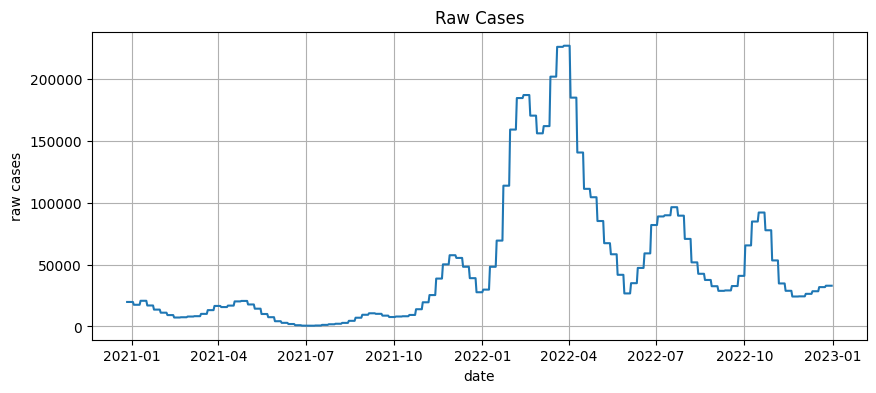

In [3]:
plt.figure()
plt.plot(df["date"], df["new_cases_smoothed"])
plt.title("Raw Cases")
plt.xlabel("date")
plt.ylabel("raw cases")
plt.show()


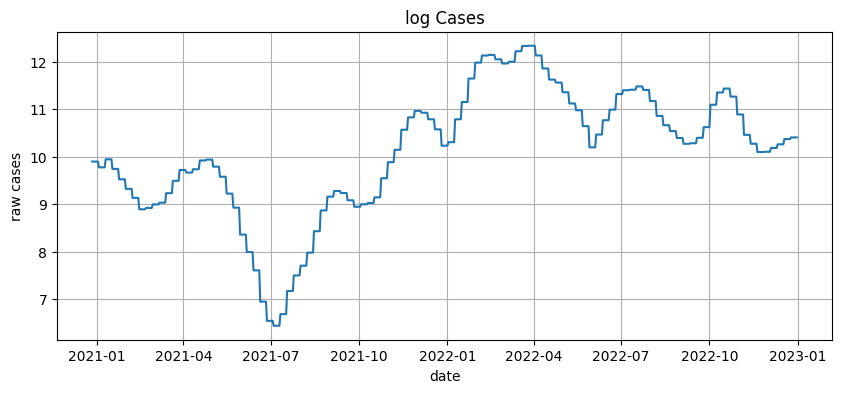

In [4]:
plt.figure()
plt.plot(df["date"], np.log(df["new_cases_smoothed"]))
plt.title("log Cases")
plt.xlabel("date")
plt.ylabel("raw cases")
plt.show()

Multiplicative, as we have small mean and small variance early, and high mean and higher variance in later time


## 5 STL Decomposition

Tasks:

1. Apply STL with `period = 7` to log cases.
2. Plot trend, seasonal, and residual components.
3. Interpret:

- Trend → what does it represent epidemiologically?
- Seasonal → reporting or biology?
- Residual → what do spikes represent?


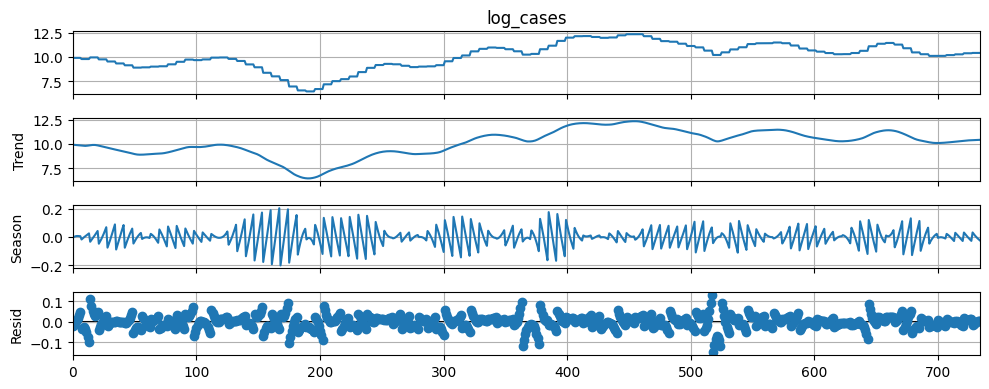

In [6]:
df['log_cases'] = np.log(df['new_cases_smoothed'])
stl = STL(df['log_cases'], period=7)
res_stl = stl.fit()
res_stl.plot()
plt.show()

3. Interpret:

- Trend → what does it represent epidemiologically? It fluctuates around 10, however it tends to fall below that around week 100 to 300 and afterwards it tends to be above that. This could mean that we have generally more cases later.
- Seasonal → reporting or biology? seems biological, as it occurs periodically
- Residual → what do spikes represent? Spikes are extremes (to inspect if they are outliers)


## 6 Anomaly Detection

We compare two methods.

---

### A) Standard Z-score

Formula:

    z = (residual - mean) / standard_deviation

An anomaly if:

    |z| > 2

Limitation:
Standard deviation is sensitive to extreme values.

---

### B) Robust MAD (Median Absolute Deviation)

Step 1: Compute median of residuals.

Step 2: Compute MAD:

    MAD = median(|residual - median|)

Step 3: Convert to robust z-score:

    robust_z = (residual - median) / (1.4826 × MAD)

Why multiply by 1.4826?
For normally distributed data, this makes MAD comparable to standard deviation.

---

### Why is MAD More Robust?

• Uses median instead of mean  
• Not strongly influenced by extreme spikes  
• Better for heavy-tailed epidemic residuals  

---

### Tasks

1. Implement both methods.
2. Compare number of detected anomalies.
3. Which seems more reasonable?


In [11]:
#z = (residual - mean) / standard_deviation
z = (res_stl.resid - res_stl.resid.mean()) / res_stl.resid.std()
anomaly_idx_z = np.where(np.abs(z) > 2)[0]

# MAD = median(|residual - median|)
MAD = np.median(np.abs(res_stl.resid - np.median(res_stl.resid)))
#robust_z = (residual - median) / (1.4826 × MAD)
robust_z = (res_stl.resid - np.median(res_stl.resid)) / (1.4826 * MAD)
anomaly_idx_robust_z = np.where(np.abs(robust_z) > 2)[0]

In [13]:
print("number of anomalies normal z: ", len(anomaly_idx_z))
print("number of anomalies robust z: ", len(anomaly_idx_robust_z))

number of anomalies normal z:  39
number of anomalies robust z:  68



## 7 Integrate ECDC Variant Data

We use weekly variant proportions from ECDC.

Steps:
1. Load weekly variant data.
2. Filter for Germany.
3. Keep only SARS-CoV-2 and proportion indicator.
4. Convert ISO week to date.
5. Identify dominant variant per week.
6. Merge into daily dataset.


In [17]:

variant_url = "https://raw.githubusercontent.com/EU-ECDC/Respiratory_viruses_weekly_data/refs/heads/main/data/variants.csv"

var = pd.read_csv(variant_url)

# Filter Germany + SARS-CoV-2 + proportion + total age
var = var[
    (var["countryname"] == "Germany") &
    (var["pathogen"] == "SARS-CoV-2") &
    (var["indicator"] == "proportion") &
    (var["age"] == "total")
].copy()

# Convert ISO week format (YYYY-Www) to date (Monday of that week)
var["date"] = pd.to_datetime(var["yearweek"] + "-1", format="%G-W%V-%u")

# Identify dominant variant per week
dominant = var.loc[var.groupby("date")["value"].idxmax()]
dominant = dominant[["date", "variant"]]

# Merge into daily dataset
df = df.merge(dominant, on="date", how="left")
df["variant"] = df["variant"].ffill()



### Tasks

1. Plot anomalies on log-case plot and color by variant.
2. Compute anomaly frequency per variant.
3. Are certain variants associated with more residual spikes?


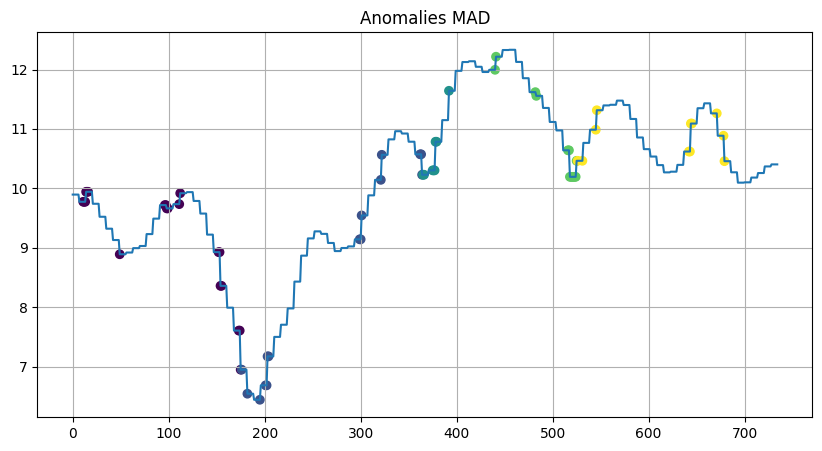

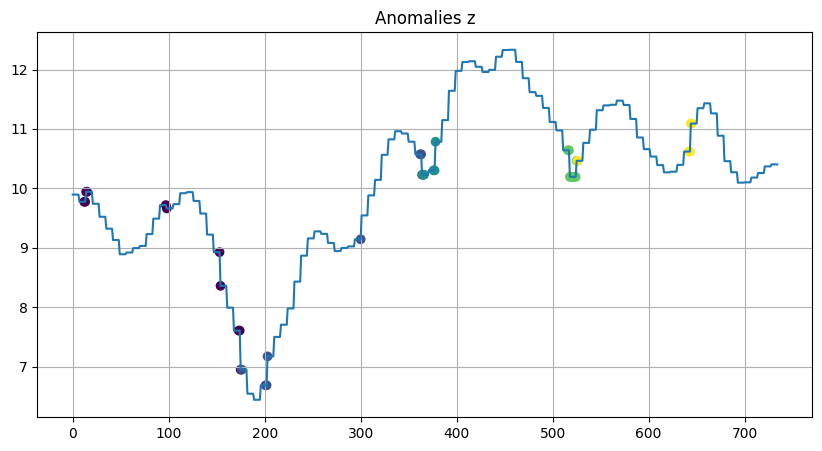

In [38]:
labels_MAD, uniques_MAD = pd.factorize(df["variant"].iloc[anomaly_idx_robust_z])

plt.figure(figsize=(10,5))
plt.plot(df['log_cases'])
plt.scatter(df['log_cases'].index[anomaly_idx_robust_z], df['log_cases'].iloc[anomaly_idx_robust_z], c = labels_MAD)
plt.title("Anomalies MAD")
plt.show()

labels_z, uniques_z = pd.factorize(df["variant"].iloc[anomaly_idx_z])

plt.figure(figsize=(10,5))
plt.plot(df['log_cases'])
plt.scatter(df['log_cases'].index[anomaly_idx_z], df['log_cases'].iloc[anomaly_idx_z], c = labels_z)
plt.title("Anomalies z")
plt.show()

In [51]:
# anomaly frequency per variant
counts_when_res_z = df['variant'].iloc[anomaly_idx_z].value_counts()
counts_when_res_z

,count
variant,
BA.2,10
B.1.617.2,8
BA.1,5
BA.5,5


In [52]:
# anomaly frequency per variant
counts_when_res = df['variant'].iloc[anomaly_idx_robust_z].value_counts()
counts_when_res

,count
variant,
B.1.617.2,15
BA.2,14
BA.5,11
BA.1,8


In [53]:
relative_count_z = (df['variant'].iloc[anomaly_idx_z].value_counts() / df['variant'].value_counts()) * 100
relative_count_z

,count
variant,
B.1.617.2,4.232804
BA.1,8.928571
BA.2,9.523810
BA.5,2.392344


In [49]:
# Are certain variants associated with more residual spikes?
relative_count = (df['variant'].iloc[anomaly_idx_robust_z].value_counts() / df['variant'].value_counts()) * 100
relative_count

# BA.1 and BA.2 have more than the other two w.r.t. their total count

,count
variant,
B.1.617.2,7.936508
BA.1,14.285714
BA.2,13.333333
BA.5,5.263158



## 8 Statistical Testing

Perform:

A) Compare stringency during anomaly vs non-anomaly (t-test).

B) Compare vaccination during anomaly vs non-anomaly.

C) Logistic regression:

    is_anomaly ~ stringency + vaccination + variant

Interpret carefully:
Does biological shift (variant) matter more than policy?


In [68]:
# A) Compare stringency during anomaly vs non-anomaly (t-test).

stringency_anomaly = df['stringency_index'].iloc[anomaly_idx_robust_z]
stringency_non_anomaly = df.drop(df.index[anomaly_idx_robust_z])["stringency_index"]

t_stat_stringency, p_value_stringency = ttest_ind(stringency_anomaly, stringency_non_anomaly)
print(t_stat_stringency, p_value_stringency)

1.346692978559652 0.17849536995562296


In [69]:
#B) Compare vaccination during anomaly vs non-anomaly.
vaccination_anomaly = df['people_vaccinated_per_hundred'].iloc[anomaly_idx_robust_z]
vaccination_non_anomaly = df.drop(df.index[anomaly_idx_robust_z])["people_vaccinated_per_hundred"]

t_stat_vaccination, p_value_vaccination = ttest_ind(vaccination_anomaly, vaccination_non_anomaly)
print(t_stat_vaccination, p_value_vaccination)

-0.721841747054834 0.47062197784989723


In [73]:
# is_anomaly ~ stringency + vaccination + variant
df["is_anomaly"] = 0
df.loc[anomaly_idx_robust_z, "is_anomaly"] = 1

mod = smf.ols(formula='is_anomaly ~ stringency_index + people_vaccinated_per_hundred + variant', data=df)

res = mod.fit()

print(res.summary())

                            OLS Regression Results                            
Dep. Variable:             is_anomaly   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     2.166
Date:                Mon, 23 Feb 2026   Prob (F-statistic):             0.0565
Time:                        14:04:36   Log-Likelihood:                -76.514
No. Observations:                 559   AIC:                             165.0
Df Residuals:                     553   BIC:                             191.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

stringency index has high p_val (0.284) and low coefficient (almost 0). The variant has much lower p_value (BA.1 has 0.033) -> it matters more than policy to explain the model


## 9 Peak Detection Using `find_peaks`

Function: `scipy.signal.find_peaks`

It detects local maxima.

Parameter:

    distance = 60

What does it control?

• Minimum number of days between detected peaks  
• Prevents detecting small fluctuations as new waves  
• Roughly ensures waves are at least ~2 months apart  

---

### Tasks

1. Detect peaks with distance=60.
2. Plot peaks on raw case data.
3. Compare with STL trend waves.




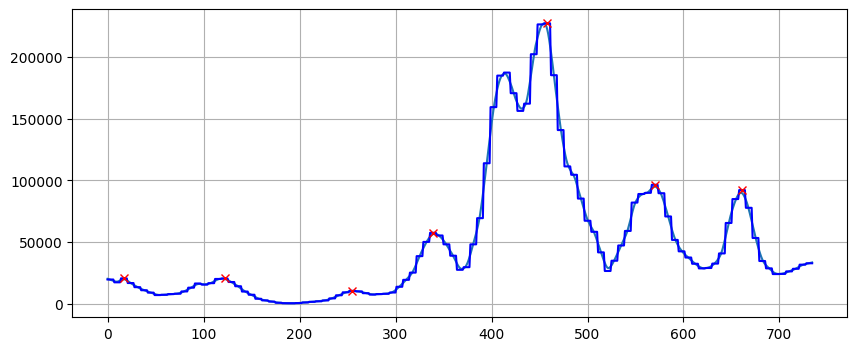

In [82]:
peaks, _ = find_peaks(df['new_cases_smoothed'], distance=60)

stl_raw = STL(df["new_cases_smoothed"], period = 7)
res_raw = stl_raw.fit()
plt.plot(res_raw.trend)

plt.plot(df['new_cases_smoothed'], c = 'blue')
plt.plot(peaks, df['new_cases_smoothed'][peaks], "x", c='red')